In [4]:
import os
import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2025-11-08 04:35:24.801280: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 04:35:25.034805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-08 04:35:26.833456: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 123.5 MB/s  0:00:040:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 136.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 299.5 MB/s  0:00:00
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
    Found existing installation: protobuf 4.23.4━━━━━━━━━━━━━━  1/16 [libclang]
    Uninstalling protobuf-4.23.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
      Successfully uninstalled protobuf-4.23.4━━━━━━━━━━━━━━━━  1/16 [libclang]
  Attempting uninstall: tensorboard╸━━━━━━━━━━━━ 11/16 [gast]ypes]
    Found existing installation: tensorboard 2.15.1━━━━━━━━━━━ 11/16 [gast]
    Uninstalling tensorboard-2.15.1:╸━━━━━━━━━━━━ 11/16 [gast]
    

In [15]:
# ----------------------------
# Set up dataset paths
# ----------------------------

DATA_DIR = "binary_model_data"     # Main dataset folder
TRAIN_DIR = os.path.join(DATA_DIR, "train")   # Training data
VAL_DIR = os.path.join(DATA_DIR, "valid")     # Validation data
TEST_DIR = os.path.join(DATA_DIR, "test")     # Test data

In [16]:
# ----------------------------
# Create output folder
# ----------------------------

OUTPUT_DIR = "./mobilenetv3_base"     # Folder to save model outputs
os.makedirs(OUTPUT_DIR, exist_ok=True) # Make directory if it doesn't exist

In [17]:
# ----------------------------
# Training parameters
# ----------------------------

IMAGE_SIZE = (224, 224)     # Input image size
BATCH_SIZE = 32             # Number of images per batch
SEED = 42                   # Random seed for reproducibility
EPOCHS = 8                  # Number of training epochs
LEARNING_RATE = 1e-4        # Learning rate for optimizer
USE_MIXED_PRECISION = True  # Enable mixed precision training

In [18]:
# ----------------------------
# Mixed precision for speed
# ----------------------------
if USE_MIXED_PRECISION:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled.")
    except Exception as e:
        print("Mixed precision not available:", e)

Mixed precision enabled.


In [19]:
# ----------------------------
# Load datasets (train/valid/test)
# ----------------------------

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(   # Load training data
    TRAIN_DIR,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(        # Load validation data
    VAL_DIR,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(        # Load test data
    TEST_DIR,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

print("Class names:", train_ds.class_names) # Show class labels found in training set

Found 12383 files belonging to 2 classes.


Found 991 files belonging to 2 classes.
Found 603 files belonging to 2 classes.
Class names: ['not_skin', 'skin']


2025-11-08 05:17:19.836776: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
# ----------------------------
# Data augmentation & preprocessing
# ----------------------------

# Apply random transformations to make the model more robust
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),      # Flip images horizontally
    layers.RandomRotation(0.06),          # Slightly rotate images
    layers.RandomZoom(0.08),              # Random zoom in/out
    layers.RandomTranslation(0.04, 0.04), # Shift images in width and height
    layers.RandomContrast(0.08)           # Adjust image contrast
])


In [21]:
# ----------------------------
# Preprocessing functions
# ----------------------------

from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# Apply augmentation and preprocessing for training data
def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32)       # Convert images to float32
    images = data_augmentation(images)         # Apply data augmentation
    images = preprocess_input(images)          # Normalize for MobileNetV3
    return images, labels

# Preprocessing for validation and test data (no augmentation)
def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32)       # Convert images to float32
    images = preprocess_input(images)          # Normalize for MobileNetV3
    return images, labels


In [22]:
# ----------------------------
# Prepare datasets for training
# ----------------------------

# Apply preprocessing, enable caching, and prefetch for faster data loading
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

In [23]:
# ----------------------------
# Build MobileNetV3-Large base
# ----------------------------

from tensorflow.keras.applications import MobileNetV3Large

base_model = MobileNetV3Large(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model to use pretrained features

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Dropout for regularization (prevents overfitting)
outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="mobilenetv3_base")
model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [24]:
# ----------------------------
# Compile and train
# ----------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, "best_base.keras"), save_best_only=True, monitor="val_loss"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

print("Training base model...") 
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Training base model...
Epoch 1/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 381s 967ms/step - accuracy: 0.7566 - auc: 0.8334 - loss: 0.5007 - precision: 0.7415 - recall: 0.7891 - val_accuracy: 0.9415 - val_auc: 0.9887 - val_loss: 0.2075 - val_precision: 0.9132 - val_recall: 0.9758 - learning_rate: 1.0000e-04
Epoch 2/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 253s 654ms/step - accuracy: 0.9363 - auc: 0.9812 - loss: 0.2046 - precision: 0.9284 - recall: 0.9457 - val_accuracy: 0.9728 - val_auc: 0.9972 - val_loss: 0.1130 - val_precision: 0.9518 - val_recall: 0.9960 - learning_rate: 1.0000e-04
Epoch 3/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 248s 641ms/step - accuracy: 0.9616 - auc: 0.9926 - loss: 0.1319 - precision: 0.9536 - recall: 0.9707 - val_accuracy: 0.9788 - val_auc: 0.9982 - val_loss: 0.0793 - val_precision: 0.9630 - val_recall: 0.9960 - learning_rate: 1.0000e-04
Epoch 4/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 248s 640ms/step - accuracy: 0.9702 - auc: 0.9947 - loss: 0.1032 - precision: 0.9618 - recall: 0.9794 - val_accuracy: 0.

In [25]:
# ----------------------------
# Save model
# ----------------------------

base_model_path = os.path.join(OUTPUT_DIR, "mobilenetv3_base.keras")
model.save(base_model_path)
print("Base model saved at:", base_model_path)

Base model saved at: ./mobilenetv3_base/mobilenetv3_base.keras


In [29]:
# ----------------------------
# Evaluate on test set
# ----------------------------

print("Evaluating on test set:\n")

# Evaluate model on test data
results = model.evaluate(test_ds, return_dict=True, verbose=0)

print("Evaluation Results:")
for name, value in results.items():
    print(f"{name.capitalize():<10}: {value:.4f}")

Evaluating on test set:



Evaluation Results:
Accuracy  : 0.9884
Auc       : 0.9990
Loss      : 0.0406
Precision : 0.9836
Recall    : 0.9934


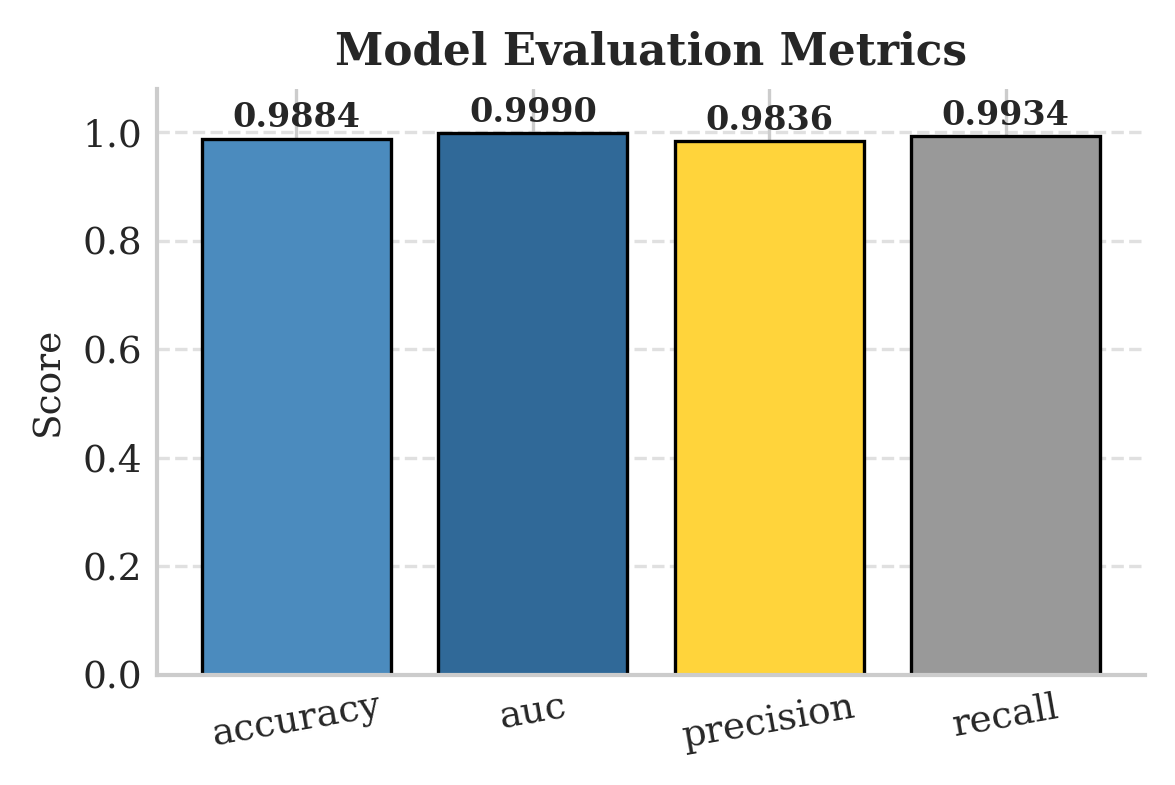

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluate the model and get results as dictionary
results = model.evaluate(test_ds, return_dict=True, verbose=0)

# Extract metrics except 'loss'
metrics = [m for m in results.keys() if m != 'loss']
values = [results[m] for m in metrics]

# --- Compact, warning-free research style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],   # Universal font, avoids missing font error
    'axes.titlesize': 11,
    'axes.labelsize': 9.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300
})

# --- Smaller figure size for paper ---
fig, ax = plt.subplots(figsize=(3.8, 2.5))  # ultra-compact for single-column layout

# Professional, distinct color palette
colors = ['#4B8BBE', '#306998', '#FFD43B', '#999999']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=0.8)

# --- Annotate each bar ---
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.008,
            f"{value:.4f}",
            ha='center', va='bottom', fontsize=8, fontweight='semibold')

# --- Titles and labels ---
ax.set_title("Model Evaluation Metrics", fontsize=10.5, fontweight='bold', pad=6)
ax.set_ylabel("Score", fontsize=9)
ax.set_ylim(0, 1.08)

# --- Clean minimal design ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=10)

# --- Tight layout for publication ---
plt.tight_layout(pad=0.3)
plt.savefig("small_research_metrics_final.png", dpi=600, bbox_inches='tight')
plt.show()


# `Fine Tuning`

In [41]:
# ==========================================================
# FINE-TUNING BLOCK (Continue after base model evaluation)
# ==========================================================

for layer in base_model.layers[:-100]:
    layer.trainable = False
for layer in base_model.layers[-100:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # Keep BN layers frozen
    else:
        layer.trainable = True   # Unfreeze the rest (Conv, Dense, etc.)

# Confirm how many layers are now trainable
trainable_count = len([l for l in base_model.layers if l.trainable])
print(f"Unfroze the last 100 layers. Total trainable layers now: {trainable_count}")

# Define a smaller learning rate for fine-tuning
FINE_TUNE_LR = 1e-5
FINE_TUNE_EPOCHS = 10

Unfroze the last 100 layers. Total trainable layers now: 76


In [42]:
# Compile model again (important after changing layer trainability)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [43]:
# Define fine-tuning callbacks
fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./mobilenetv3_base/best_model_fine_tune.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

In [44]:
# Continue training (fine-tuning)
history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=EPOCHS,  # continue from previous epoch count
    callbacks=fine_tune_callbacks
)

Epoch 9/18
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9819 - auc: 0.9977 - loss: 0.0598 - precision: 0.9743 - recall: 0.9894
Epoch 9: val_loss improved from None to 0.03703, saving model to ./mobilenetv3_base/best_model_fine_tune.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 260s 658ms/step - accuracy: 0.9832 - auc: 0.9977 - loss: 0.0581 - precision: 0.9777 - recall: 0.9890 - val_accuracy: 0.9909 - val_auc: 0.9994 - val_loss: 0.0370 - val_precision: 0.9860 - val_recall: 0.9960 - learning_rate: 1.0000e-05
Epoch 10/18
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9825 - auc: 0.9976 - loss: 0.0602 - precision: 0.9749 - recall: 0.9899
Epoch 10: val_loss improved from 0.03703 to 0.03659, saving model to ./mobilenetv3_base/best_model_fine_tune.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 254s 657ms/step - accuracy: 0.9837 - auc: 0.9977 - loss: 0.0579 - precision: 0.9780 - recall: 0.9897 - val_accuracy: 0.9909 - val_auc: 0.9994 - val_loss: 0.0366 - val_precision: 0.9860 - val_recall: 0.99

In [45]:
fine_tuned_model_path = "./mobilenetv3_base/mobilenetv3_fine_tune.keras"
model.save(fine_tuned_model_path)
print("\nFine-tuned model saved at:", fine_tuned_model_path)


Fine-tuned model saved at: ./mobilenetv3_base/mobilenetv3_fine_tune.keras


In [47]:
print("\nEvaluating fine-tuned model on test set:")

# Evaluate model on test data
fine_tune_results = model.evaluate(test_ds, return_dict=True, verbose=0)

print("Evaluation Results:")
for name, value in results.items():
    print(f"{name.capitalize():<10}: {value:.4f}")


Evaluating fine-tuned model on test set:


Evaluation Results:
Accuracy  : 0.9884
Auc       : 0.9990
Loss      : 0.0406
Precision : 0.9836
Recall    : 0.9934
